<a href="https://www.kaggle.com/code/samithsachidanandan/building-a-poisson-regression-model?scriptVersionId=341549017" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# Generate count data (Poisson distributed)

In [2]:

np.random.seed(42)
torch.manual_seed(42)

X = np.random.randn(500, 5).astype(np.float32)
# Generate Poisson counts based on exponential of linear combination
true_lambda = np.exp(0.5 * X[:, 0] + 0.3 * X[:, 1] + 1.0)
y = np.random.poisson(true_lambda).astype(np.float32)


# Split data

In [3]:


X_train, X_test = X[:400], X[400:]
y_train, y_test = y[:400], y[400:]

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train).unsqueeze(1)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test).unsqueeze(1)

# Model 1: Using MSE loss (wrong assumption - Gaussian)

In [4]:

class PoissonNetMSE(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        # Linear output - can be negative
        return self.net(x)

# Model 2: Using Poisson loss (correct exponential family assumption)

In [5]:

class PoissonNetPoisson(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        # Exponential output - always positive, matches Poisson mean
        return torch.exp(self.net(x))

# Poisson loss (negative log-likelihood)

In [6]:


def poisson_loss(y_pred, y_true):
    # L = -y*log(lambda) + lambda
    return (-y_true * torch.log(y_pred + 1e-8) + y_pred).mean()

# Training functions

In [7]:

def train_mse_model(model, X_train, y_train, X_test, y_test, epochs=100):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    train_losses = []
    test_losses = []
    test_mape = []  # Mean absolute percentage error
    
    for epoch in range(epochs):
        # Training
        y_pred_train = model(X_train_t)
        loss = criterion(y_pred_train, y_train_t)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test_t)
            test_loss = criterion(y_pred_test, y_test_t)
            mape = torch.mean(torch.abs((y_pred_test - y_test_t) / (y_test_t + 1e-8))).item()
            
        test_losses.append(test_loss.item())
        test_mape.append(mape)
        model.train()
    
    return train_losses, test_losses, test_mape

In [8]:
def train_poisson_model(model, X_train, y_train, X_test, y_test, epochs=100):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    train_losses = []
    test_losses = []
    test_mape = []
    
    for epoch in range(epochs):
        # Training
        y_pred_train = model(X_train_t)
        loss = poisson_loss(y_pred_train, y_train_t)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test_t)
            test_loss = poisson_loss(y_pred_test, y_test_t)
            mape = torch.mean(torch.abs((y_pred_test - y_test_t) / (y_test_t + 1e-8))).item()
        
        test_losses.append(test_loss.item())
        test_mape.append(mape)
        model.train()
    
    return train_losses, test_losses, test_mape

# Train both

In [9]:
print("Training MSE-based model (wrong exponential family assumption)...")
model_mse = PoissonNetMSE()
train_mse, test_mse, mape_mse = train_mse_model(model_mse, X_train, y_train, X_test, y_test, epochs=100)

print("Training Poisson-based model (correct exponential family assumption)...")
model_poisson = PoissonNetPoisson()
train_poisson, test_poisson, mape_poisson = train_poisson_model(model_poisson, X_train, y_train, X_test, y_test, epochs=100)

Training MSE-based model (wrong exponential family assumption)...
Training Poisson-based model (correct exponential family assumption)...


# Plot

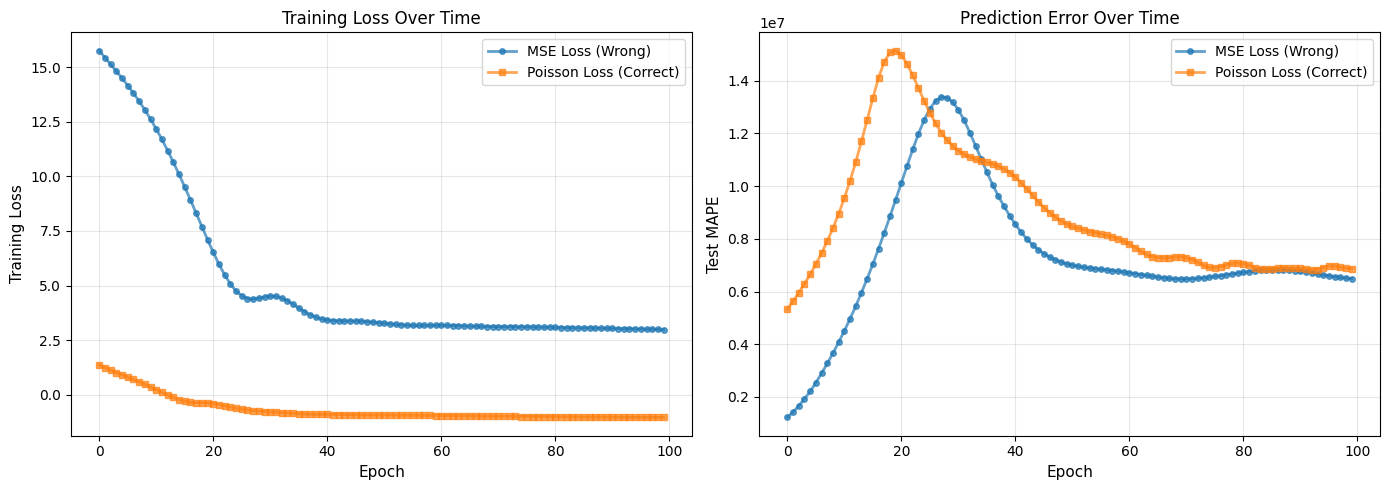

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Loss
ax = axes[0]
ax.plot(train_mse, 'o-', label='MSE Loss (Wrong)', alpha=0.7, linewidth=2, markersize=4)
ax.plot(train_poisson, 's-', label='Poisson Loss (Correct)', alpha=0.7, linewidth=2, markersize=4)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Training Loss', fontsize=11)
ax.set_title('Training Loss Over Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Test MAPE (Mean Absolute Percentage Error)
ax = axes[1]
ax.plot(mape_mse, 'o-', label='MSE Loss (Wrong)', alpha=0.7, linewidth=2, markersize=4)
ax.plot(mape_poisson, 's-', label='Poisson Loss (Correct)', alpha=0.7, linewidth=2, markersize=4)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Test MAPE', fontsize=11)
ax.set_title('Prediction Error Over Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




# Final comparison

In [11]:

print("\n" + "=" * 60)
print("FINAL RESULTS ON TEST SET")
print("=" * 60)

model_mse.eval()
model_poisson.eval()

with torch.no_grad():
    y_pred_mse = model_mse(X_test_t).numpy()
    y_pred_poisson = model_poisson(X_test_t).numpy()
    
    mape_final_mse = np.mean(np.abs((y_pred_mse - y_test) / (y_test + 1e-8)))
    mape_final_poisson = np.mean(np.abs((y_pred_poisson - y_test) / (y_test + 1e-8)))
    
    rmse_mse = np.sqrt(np.mean((y_pred_mse - y_test.reshape(-1, 1))**2))
    rmse_poisson = np.sqrt(np.mean((y_pred_poisson - y_test.reshape(-1, 1))**2))

print(f"MSE Model:")
print(f"  RMSE: {rmse_mse:.4f}")
print(f"  MAPE: {mape_final_mse:.4f}")

print(f"\nPoisson Model:")
print(f"  RMSE: {rmse_poisson:.4f}")
print(f"  MAPE: {mape_final_poisson:.4f}")

print(f"\nImprovement (Poisson vs MSE):")
print(f"  RMSE reduction: {(1 - rmse_poisson/rmse_mse)*100:.1f}%")
print(f"  MAPE reduction: {(1 - mape_final_poisson/mape_final_mse)*100:.1f}%")


FINAL RESULTS ON TEST SET
MSE Model:
  RMSE: 2.0315
  MAPE: 21411680.0000

Poisson Model:
  RMSE: 1.9228
  MAPE: 22079304.0000

Improvement (Poisson vs MSE):
  RMSE reduction: 5.4%
  MAPE reduction: -3.1%
